In [ ]:
'''
EDA: 探索性数据分析
date: 2026-01-22
target:深度分析数据集特征，为特征工程和模型选择提供依据
'''

'\nnotebooks.01_EDA.ipynb 的 Docstring\nEDA: 探索性数据分析\ndate: 2026-01-22\ntarget:深度分析数据集特征，为特征工程和模型选择提供依据\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime,timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
df = pd.read_csv("../data/raw/online_data.csv")
print(f"数据集的形状: {df.shape}")
print(f"数据集的时间跨度: {df['Date'].min()} 至 {df['Date'].max()}")
print("数据集的前五行:")
display(df.head())

数据集的形状: (11429826, 7)
数据集的时间跨度: 20160101.0 至 20160630.0
数据集的前五行:


,User_id,Merchant_id,Action,Coupon_id,Discount_rate,Date_received,Date
0,13740231,18907,2,100017492,500:50,20160513.0,NaN
1,13740231,34805,1,NaN,NaN,NaN,20160321.0
2,14336199,18907,0,NaN,NaN,NaN,20160618.0
3,14336199,18907,0,NaN,NaN,NaN,20160618.0
4,14336199,18907,0,NaN,NaN,NaN,20160618.0


In [4]:
print(f"数据类型:\n{df.dtypes}")

数据类型:
User_id            int64
Merchant_id        int64
Action             int64
Coupon_id         object
Discount_rate     object
Date_received    float64
Date             float64
dtype: object


In [5]:
print("\n基本统计信息:")
print(df.describe())


基本统计信息:
            User_id   Merchant_id        Action  Date_received          Date
count  1.142983e+07  1.142983e+07  1.142983e+07   8.723570e+05  1.077393e+07
mean   1.074683e+07  3.436686e+04  2.348193e-01   2.016037e+07  2.016039e+07
std    4.137712e+06  1.441243e+04  5.426314e-01   1.560031e+02  1.732371e+02
min    4.000000e+00  1.000100e+04  0.000000e+00   2.016010e+07  2.016010e+07
25%    1.019827e+07  2.090100e+04  0.000000e+00   2.016023e+07  2.016023e+07
50%    1.196970e+07  3.420000e+04  0.000000e+00   2.016040e+07  2.016041e+07
75%    1.373506e+07  4.741500e+04  0.000000e+00   2.016051e+07  2.016052e+07
max    1.550000e+07  6.000000e+04  2.000000e+00   2.016062e+07  2.016063e+07


In [6]:
print("缺失值统计：")
print(df.isnull().sum())

缺失值统计：
User_id                 0
Merchant_id             0
Action                  0
Coupon_id        10557469
Discount_rate    10557469
Date_received    10557469
Date               655898
dtype: int64


In [7]:
print(f"唯一用户数：{df['User_id'].nunique()}")
print(f"唯一商户数：{df['Merchant_id'].nunique()}")
print(f"总行为记录数：{len(df):,}")

唯一用户数：762858
唯一商户数：7999
总行为记录数：11,429,826


In [8]:
# 行为类型分布
action_dist = df['Action'].value_counts().sort_index()
for action,count in action_dist.items():
    action_name = {0:'点击',1:'购买',2:'领券'}.get(action,f'未知{action}')
    print(f"{action_name}:{count:,}({count/len(df)*100:.2f}%)")

点击:9,401,780(82.26%)
购买:1,372,148(12.00%)
领券:655,898(5.74%)


In [9]:
# 计算整体CVR
total_clicks = action_dist.get(0, 0)
total_purchases = action_dist.get(1, 0)
overall_cvr = (total_purchases / total_clicks * 100) if total_clicks > 0 else 0
print(f"整体点击转化率(CVR): {overall_cvr:.2f}%")

整体点击转化率(CVR): 14.59%


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
df['Date_received'] = pd.to_datetime(df['Date_received'], format='%Y%m%d')

print(f"\nDate_received (领券日期):")
if df['Date_received'].notna().sum() > 0:
    print(f"  时间范围: {df['Date_received'].min()} 至 {df['Date_received'].max()}")

print(f"\nDate (消费日期):")
if df['Date'].notna().sum() > 0:
    print(f"  时间范围: {df['Date'].min()} 至 {df['Date'].max()}")


Date_received (领券日期):
  有效记录: 872,357
  缺失记录: 10,557,469
  时间范围: 2016-01-01 00:00:00 至 2016-06-15 00:00:00

Date (消费日期):
  有效记录: 10,773,928
  缺失记录: 655,898
  时间范围: 2016-01-01 00:00:00 至 2016-06-30 00:00:00


In [11]:
# 优惠券使用情况分析
coupon_used =df[(df['Date'].notna()) & (df['Coupon_id'].notna())]
coupon_not_used = df[(df['Date'].isna()) & (df['Coupon_id'].notna())]
no_coupon_purchase = df[(df['Date'].notna()) & (df['Coupon_id'].isna())]
print(f"\n优惠券使用情况:")
print(f" 领券且使用： {len(coupon_used):,} ")
print(f" 领券未使用： {len(coupon_not_used):,} ")
print(f" 未领券购买： {len(no_coupon_purchase):,} ")

if len(coupon_used) + len(coupon_not_used) > 0:
    redemption_rate = len(coupon_used) / (len(coupon_used) + len(coupon_not_used))
    print(f" 优惠券使用率: {redemption_rate*100:.2f}%")


优惠券使用情况:
 领券且使用： 216,459 
 领券未使用： 655,898 
 未领券购买： 10,557,469 
 优惠券使用率: 24.81%


**时间维度分析：**
1. 每日购买趋势-使用Date字段
2. 每日领券趋势-使用Date_received字段
3. 按月统计
4. 周期性分析

In [12]:
# 提取月份
df['Month'] = df['Date'].dt.month
df['Month_received'] = df['Date_received'].dt.month

In [13]:
# 1.每日购买趋势
daily_purchase = df[df['Date'].notna()].groupby(df['Date'].dt.date).size()

# 2.每日领券趋势
daily_coupon = df[df['Date_received'].notna()].groupby(df['Date_received'].dt.date).size()

# 3.按月统计
monthly_stats = []
for month in range(1,7):
    # 购买和点击使用Date字段
    month_data = df[df['Month'] == month]
    if 'Action' in df.columns:
        clicks = (month_data['Action'] == 0).sum()
        purchases = (month_data['Action'] == 1).sum()
    else:
        clicks = 0
        purchases = len(month_data[month_data['Date'].notna()])
    
    # 领券使用Date_received字段
    coupons = len(df[(df['Month_received'] == month)])
    # 用券消费
    coupon_purchases = len(df[(df['Month'] == month) &
                              (df['Coupon_id'].notna()) &
                              (df['Date'].notna())])
    # 无券消费
    no_coupon_purchases = len(df[(df['Month'] == month) &
                                 (df['Coupon_id'].isna()) &
                                 (df['Date'].notna())])
    stats = {
        'Month': month,
        'Clicks': clicks,
        'Purchases': purchases,
        'Coupons_Received': coupons,
        'Coupon_Purchases': coupon_purchases,
        'No_Coupon_Purchases': no_coupon_purchases,
        'CVR (%)': round(purchases / clicks * 100,2) if clicks > 0 else 0
    }
    monthly_stats.append(stats)
monthly_df = pd.DataFrame(monthly_stats)
print("\n按月统计:")
print(monthly_df)


按月统计:
   Month   Clicks  Purchases  Coupons_Received  Coupon_Purchases  \
0      1  1621251     220983            131549             40571   
1      2   913152     124490             93621             18419   
2      3  1696493     249532            191191             44350   
3      4  1575022     247493            169880             43481   
4      5  1674959     270680            182856             44105   
5      6  1920903     258970            103260             25533   

   No_Coupon_Purchases  CVR (%)  
0              1801663    13.63  
1              1019223    13.63  
2              1901675    14.71  
3              1779034    15.71  
4              1901534    16.16  
5              2154340    13.48  


In [14]:
# 验证
print("\n 数据验证:")
print(f" 按月购买总数：{monthly_df['Purchases'].sum():,}")
print(f" 按月领券总数：{monthly_df['Coupons_Received'].sum():,}")
print(f" 全量有Date的记录：{df['Date'].notna().sum():,}")
print(f" 全量有Date_received的记录：{df['Date_received'].notna().sum():,}")


 数据验证:
 按月购买总数：1,372,148
 按月领券总数：872,357
 全量有Date的记录：10,773,928
 全量有Date_received的记录：872,357


In [15]:
# 4.周期性分析
# 星期几分布
if df['Date'].notna().sum() > 0:
    df['Weekday'] = df['Date'].dt.dayofweek
    weekday_dist = df[df['Date'].notna()]['Weekday'].value_counts().sort_index()
    weekday_names = ['星期一','星期二','星期三','星期四','星期五','星期六','星期日']
    print("\n按星期几分布:")
    for day,count in weekday_dist.items():
        if day < 7:
            print(f" {weekday_names[int(day)]}: {count:,} ")


按星期几分布:
 星期一: 1,665,941 
 星期二: 1,672,743 
 星期三: 1,637,232 
 星期四: 1,610,689 
 星期五: 1,551,545 
 星期六: 1,332,611 
 星期日: 1,303,167 


In [16]:
# 领券到使用的时间间隔分析
if len(coupon_used) > 0:
    coupon_used_copy = coupon_used.copy()
    coupon_used_copy['Days_to_use'] = (coupon_used_copy['Date'] - coupon_used_copy['Date_received']).dt.days

    print(f"\n时间间隔统计:")
    print(coupon_used_copy['Days_to_use'].describe())
    print(f"\n时间间隔分布:")
    print(f" 当天使用: {(coupon_used_copy['Days_to_use'] == 0).sum():,}")
    print(f" 1-3天: {((coupon_used_copy['Days_to_use'] >= 1) & (coupon_used_copy['Days_to_use'] <= 3)).sum():,}")
    print(f" 4-7天: {((coupon_used_copy['Days_to_use'] >= 4) & (coupon_used_copy['Days_to_use'] <= 7)).sum():,}")
    print(f" 8-15天: {((coupon_used_copy['Days_to_use'] >= 8) & (coupon_used_copy['Days_to_use'] <= 15)).sum():,}")
    print(f" 15天以上: {(coupon_used_copy['Days_to_use'] > 15).sum():,}")
    avg_days = coupon_used_copy['Days_to_use'].mean()
    median_days = coupon_used_copy['Days_to_use'].median()
    print(f"\n平均间隔: {avg_days:.1f}天")
    print(f"中位数间隔: {median_days:.0f}天")


时间间隔统计:
count    216459.000000
mean          0.903709
std           5.744698
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         171.000000
Name: Days_to_use, dtype: float64

时间间隔分布:
 当天使用: 192,809
 1-3天: 14,261
 4-7天: 3,518
 8-15天: 2,388
 15天以上: 3,483

平均间隔: 0.9天
中位数间隔: 0天


In [17]:
# # 用户维度分析
# user_stats = df.groupby('User_id').agg({
#     'Date': lambda x: x.notna().sum(), # 购买次数
#     'Date_received': lambda x: x.notna().sum(), # 领券次数
#     'Coupon_id': lambda x: (x.notna() & df.loc[x.index, 'Date'].notna()).sum() # 用券购买次数
#     }).rename(columns={
#         'Date': 'Purchase_Count',
#         'Date_received': 'Coupon_Count',
#         'Coupon_id': 'Coupon_Purchase_Count'
#         })

# user_stats['No_Coupon_Purchase_Count'] = user_stats['Purchase_Count'] - user_stats['Coupon_Purchase_Count']

# print("\n用户行为统计:")
# print(user_stats.describe())
# # 用户分层
# print("\n用户分层(按购买次数):")
# purchase_segments = pd.cut(user_stats['Purchase_Count'],
# bins=[-1, 0, 1, 3, 10, 1000],
# labels=['未购买', '购买1次', '购买2-3次', '购买4-10次', '购买10次以上'])
# print(purchase_segments.value_counts().sort_index())

In [18]:
'''
优化用户维度分析部分,避免使用lambda表达式,提升性能
优化说明：
原代码的groupby.add中使用了三个Lambda函数,其中还包含了df.loc的行索引操作,在处理数据量较大的时候会导致
大量的Python函数调用开销和重复的外部索引查找操作(在groupby内部去访问外部的df.loc非常缓慢),极大地降低性能。
优化建议：
通过预计算布尔标志位(向量化操作),然后使用Pandas的内置聚合函数来计算购买次数、领券次数和用券购买次数,
避免了Lambda函数的使用和外部索引访问,大幅提升了性能。
'''
# 预计算"用券购买"逻辑，当Coupon_id和Date都不为空时，认为是用券购买
df['is_coupon_purchase'] = (df['Coupon_id'].notna() & df['Date'].notna())
# 使用内置函数，避免使用lambda表达式的性能问题
user_stats = df.groupby('User_id').agg({'Date':'count', # 购买次数
                                       'Date_received':'count', # 领券次数
                                       'is_coupon_purchase':'sum' # 用券购买次数
                                       }).rename(columns={
                                             'Date': 'Purchase_Count',
                                             'Date_received': 'Coupon_Count',
                                             'is_coupon_purchase': 'Coupon_Purchase_Count'
                                       })
# 计算无券购买次数并清理临时列
user_stats['No_Coupon_Purchase_Count'] = user_stats['Purchase_Count'] - user_stats['Coupon_Purchase_Count']
df.drop(columns=['is_coupon_purchase'], inplace=True)
print("\n用户行为统计:")
print(user_stats.describe())
# 用户分层
print("\n用户分层(按购买次数):")
purchase_segments = pd.cut(user_stats['Purchase_Count'],
bins=[-1, 0, 1, 3, 10, 1000],
labels=['未购买', '购买1次', '购买2-3次', '购买4-10次', '购买10次以上'])
print(purchase_segments.value_counts().sort_index())


用户行为统计:
       Purchase_Count   Coupon_Count  Coupon_Purchase_Count  \
count   762858.000000  762858.000000          762858.000000   
mean        14.123111       1.143538               0.283747   
std         34.512140       3.041212               1.096233   
min          0.000000       0.000000               0.000000   
25%          2.000000       0.000000               0.000000   
50%          6.000000       0.000000               0.000000   
75%         15.000000       1.000000               0.000000   
max       5786.000000     240.000000              81.000000   

       No_Coupon_Purchase_Count  
count             762858.000000  
mean                  13.839363  
std                   34.355595  
min                    0.000000  
25%                    2.000000  
50%                    6.000000  
75%                   14.000000  
max                 5786.000000  

用户分层(按购买次数):
Purchase_Count
未购买         27182
购买1次       108960
购买2-3次     135285
购买4-10次    234185
购买10次以上    25717

In [19]:
# 复购率分析
# 1-3月活跃用户
train_users = df[df['Month'].isin([1, 2, 3])]['User_id'].unique()
print(f"1-3月活跃用户数: {len(train_users):,}")
# 各月复购率
for test_month in [4, 5, 6]:
    month_buyers = df[(df['Month'] == test_month) & (df['Date'].notna())]['User_id'].unique()
    repurchase_users = set(train_users) & set(month_buyers)
    repurchase_rate = len(repurchase_users) / len(train_users) * 100
    print(f"\n{test_month}月:")
    print(f" 购买用户数: {len(month_buyers):,}")
    print(f" 复购用户数: {len(repurchase_users):,}")
    print(f" 复购率: {repurchase_rate:.2f}%")

1-3月活跃用户数: 544,307

4月:
 购买用户数: 339,359
 复购用户数: 261,280
 复购率: 48.00%

5月:
 购买用户数: 348,732
 复购用户数: 257,987
 复购率: 47.40%

6月:
 购买用户数: 364,050
 复购用户数: 257,397
 复购率: 47.29%


**EDA可视化图表：**
1. 子图1-每日趋势(购买+领券)
2. 子图2-按月统计
3. 子图3-CVR趋势
4. 子图4-优惠券使用趋势
5. 子图5-领券到使用时间间隔
6. 子图6-用户购买次数分布
7. 子图7-星期几分布
8. 子图8-复购率对比
9. 子图9-券核销率

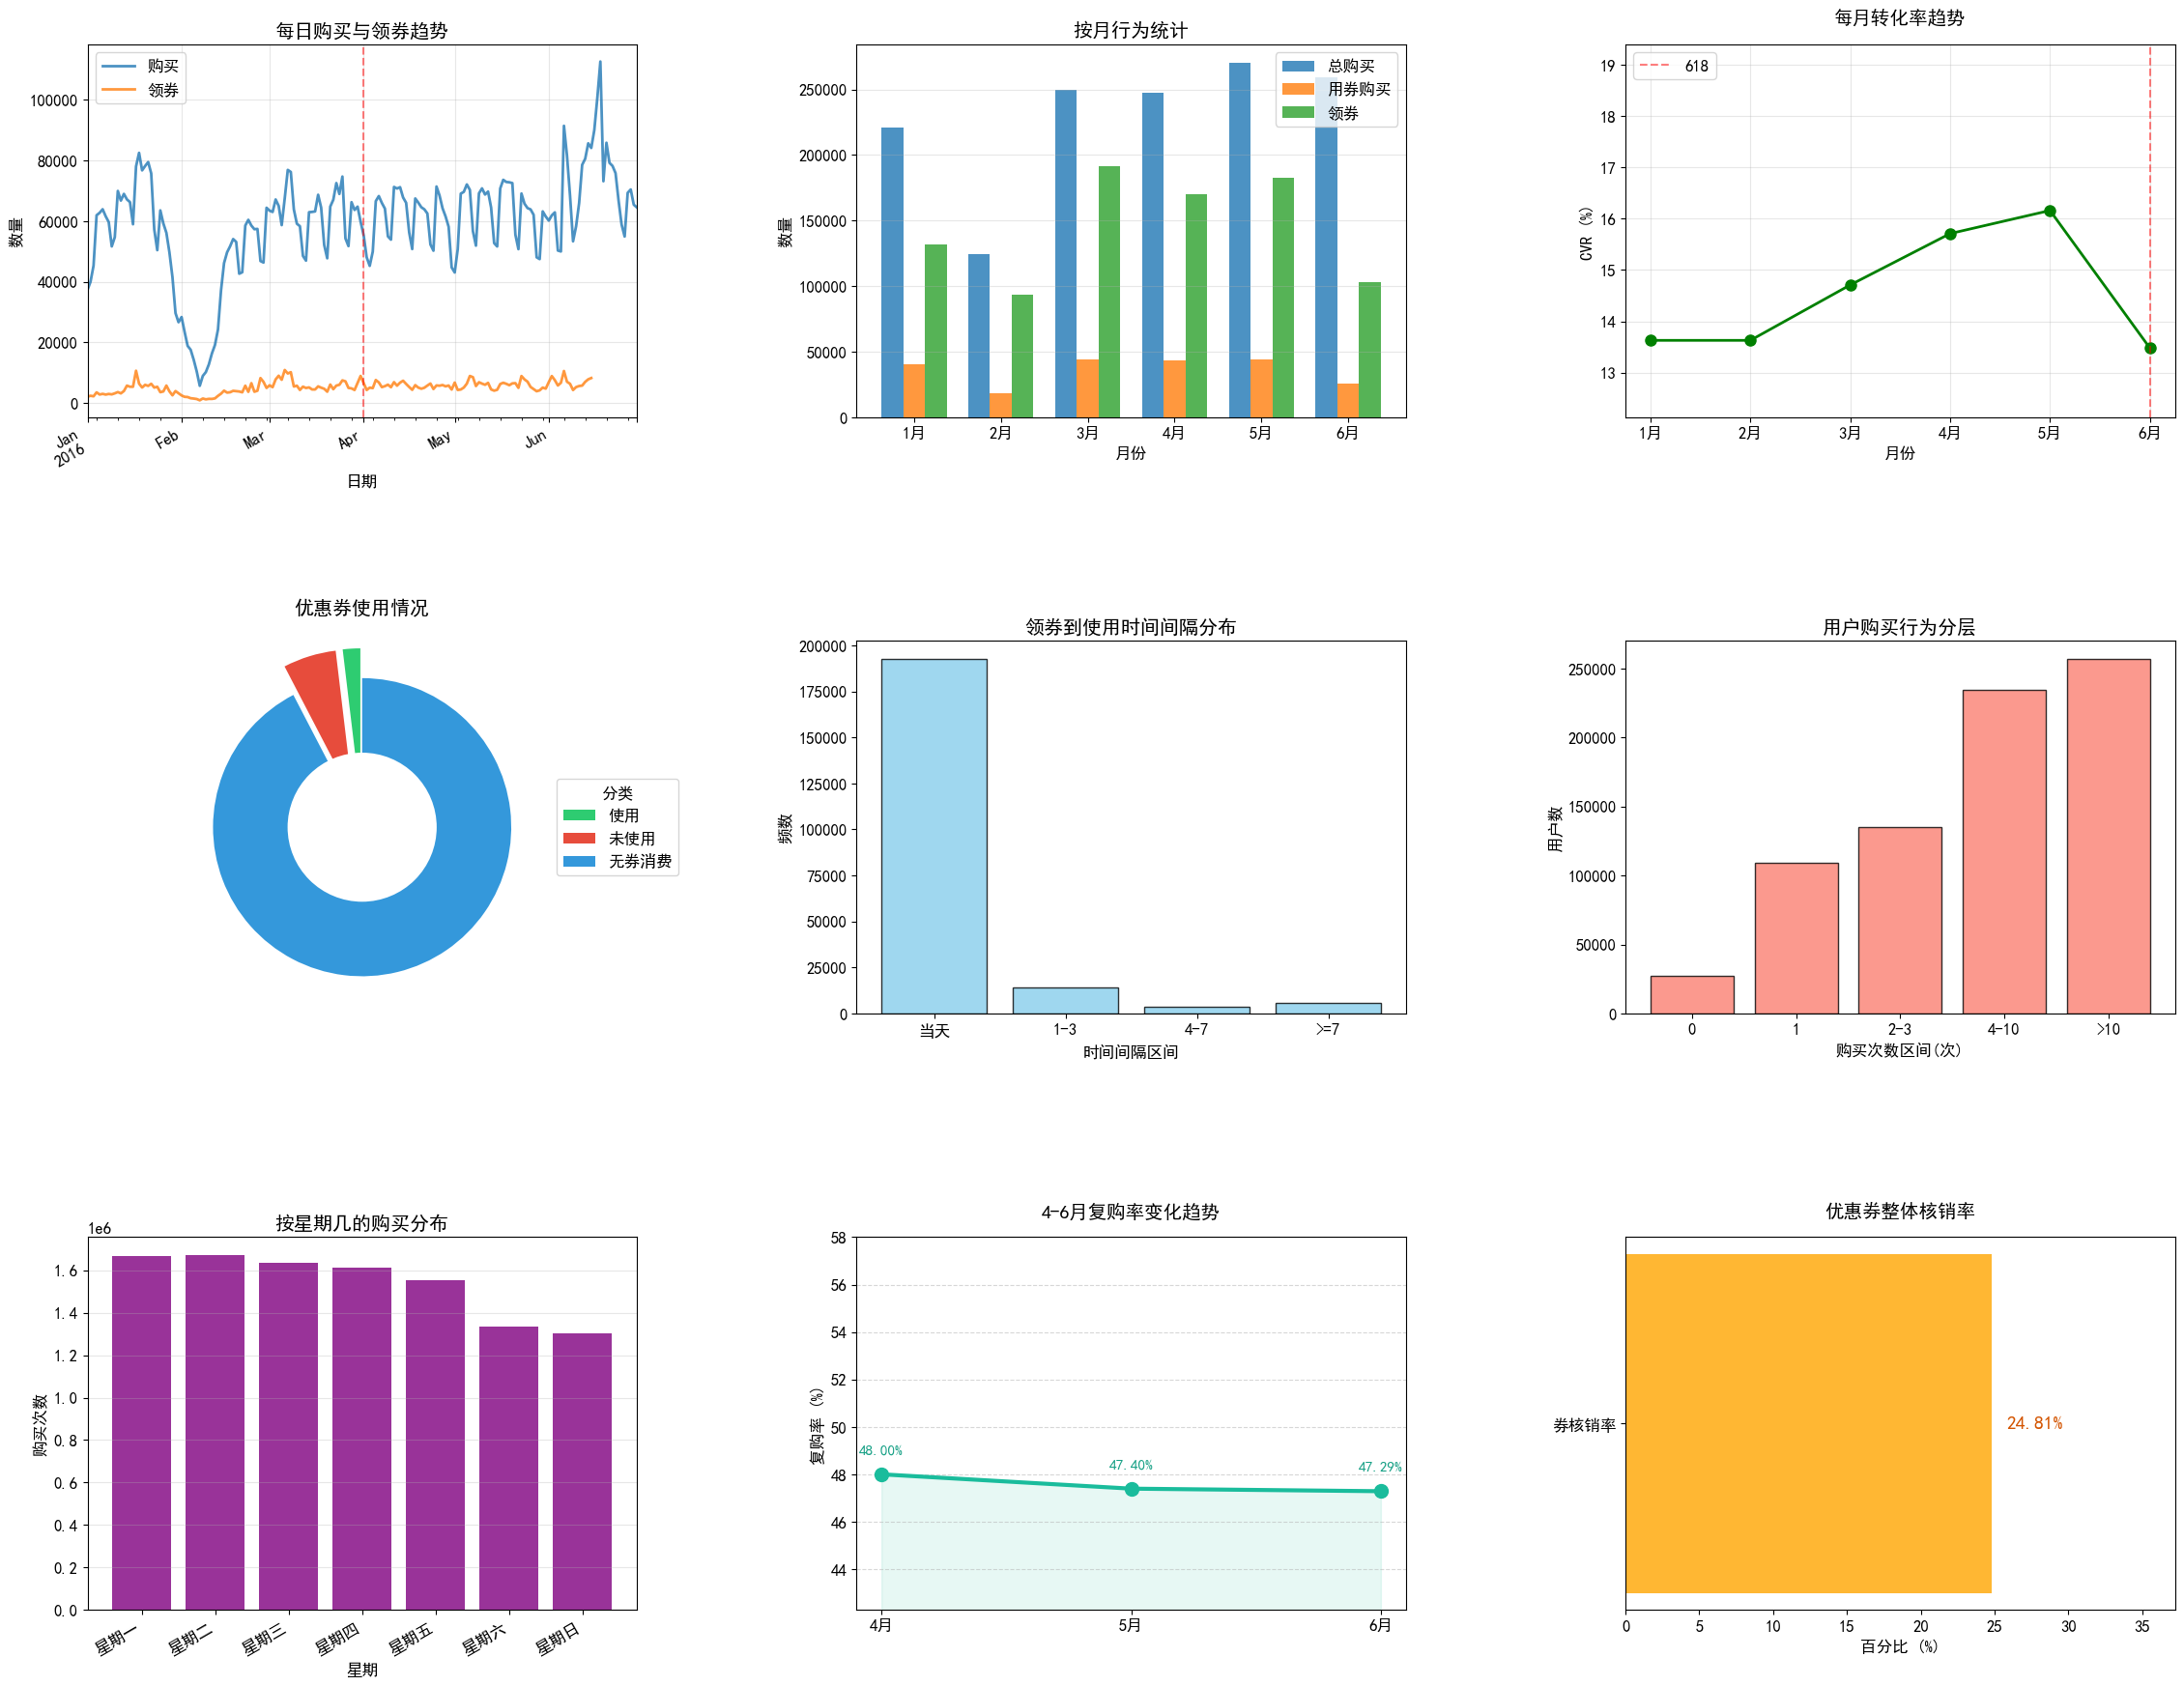

In [20]:
plt.clf()          # 清空当前画布
plt.close('all')   # 关闭所有残留的后台图表，防止环境干扰

# 强制创建一个巨大的画布对象，宽24，高18
fig = plt.figure(figsize=(24, 18), facecolor='white') 
plt.rcParams['font.size'] = 12

# 子图1: 每日趋势（购买+领券）
ax1 = plt.subplot(3, 3, 1)
daily_purchase_series = pd.Series(daily_purchase.values, index=pd.to_datetime(daily_purchase.index))
daily_coupon_series = pd.Series(daily_coupon.values, index=pd.to_datetime(daily_coupon.index))
daily_purchase_series.plot(ax=ax1, label='购买', linewidth=2, alpha=0.8)
daily_coupon_series.plot(ax=ax1, label='领券', linewidth=2, alpha=0.8)
ax1.set_title('每日购买与领券趋势', fontweight='bold')
ax1.set_xlabel('日期')
ax1.set_ylabel('数量')
# 将图例移到左上角，避免遮挡数据
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=pd.Timestamp('2016-04-01'), color='red', linestyle='--', alpha=0.5)
# 旋转X轴日期避免重叠
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ------------------------------------------------------------------
# 子图2: 按月统计
ax2 = plt.subplot(3, 3, 2)
x = monthly_df['Month']
width = 0.25
ax2.bar(x - width, monthly_df['Purchases'], width, label='总购买', alpha=0.8)
ax2.bar(x, monthly_df['Coupon_Purchases'], width, label='用券购买', alpha=0.8)
ax2.bar(x + width, monthly_df['Coupons_Received'], width, label='领券', alpha=0.8)
ax2.set_xlabel('月份')
ax2.set_ylabel('数量')
ax2.set_title('按月行为统计', fontweight='bold')
# 修复X轴刻度显示问题，并调整图例
ax2.set_xticks(x)
ax2.set_xticklabels([f'{int(m)}月' for m in x])
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)

# ------------------------------------------------------------------
# 子图3: CVR趋势
ax3 = plt.subplot(3, 3, 3)
ax3.plot(monthly_df['Month'], monthly_df['CVR (%)'], marker='o', linewidth=2, markersize=8, color='green')
ax3.set_xlabel('月份')
ax3.set_ylabel('CVR (%)')
ax3.set_title('每月转化率趋势', fontweight='bold', fontsize=14, pad=15)
ax3.grid(True, alpha=0.3)
ax3.axvline(x=6, color='red', linestyle='--', alpha=0.5, label='618')
ax3.set_xticks(monthly_df['Month'])
ax3.set_xticklabels([f'{int(m)}月' for m in monthly_df['Month']])
# 稍微拉高Y轴上限，给图例和点留空间
ax3.set_ylim(monthly_df['CVR (%)'].min() * 0.9, monthly_df['CVR (%)'].max() * 1.2)
ax3.legend(loc='upper left')

# ------------------------------------------------------------------
# 子图4: 优惠券使用情况
ax4 = plt.subplot(3, 3, 4)
labels = ['使用', '未使用', '无券消费']
sizes = [len(coupon_used), len(coupon_not_used), len(no_coupon_purchase)]
colors = ['#2ecc71', '#e74c3c', '#3498db']
explode = (0.2, 0.2, 0)  # 将占比小的两个部分偏移出来
# 去掉 autopct 参数，移除数字占比
wedges, texts = ax4.pie(sizes, explode=explode, colors=colors, 
                        startangle=90, textprops={'fontsize': 9})
# 使用图例显示分类
ax4.legend(wedges, labels, title="分类", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
centre_circle = plt.Circle((0,0), 0.50, fc='white')
ax4.add_artist(centre_circle)
ax4.set_title('优惠券使用情况', fontweight='bold', pad=20)

# ------------------------------------------------------------------
'''
# 子图5: 领券到使用时间间隔
因绝大数值分布在0,无法清晰展示时间间隔分布,
改为Bar Chart表示
'''
if len(coupon_used) > 0:
    ax5 = plt.subplot(3, 3, 5)
    # 将连续天数划分为离散区间
    interval_counts = {
        '当天': (coupon_used_copy['Days_to_use'] == 0).sum(),
        '1-3': ((coupon_used_copy['Days_to_use'] >= 1) & (coupon_used_copy['Days_to_use'] <= 3)).sum(),
        '4-7': ((coupon_used_copy['Days_to_use'] >= 4) & (coupon_used_copy['Days_to_use'] <= 7)).sum(),
        '>=7': (coupon_used_copy['Days_to_use'] > 7).sum()
    }
    
    ax5.bar(interval_counts.keys(), interval_counts.values(), color='skyblue', edgecolor='black', alpha=0.8)
    ax5.set_xlabel('时间间隔区间')
    ax5.set_ylabel('频数')
    ax5.set_title('领券到使用时间间隔分布', fontweight='bold')

# ------------------------------------------------------------------
'''
# 子图6: 用户购买次数分布
由于大部分数据都挤在一条柱子里了，
图像可视化不清晰,改为Binned Bar Chart表示
'''
# 子图6: 用户购买次数分层分布
ax6 = plt.subplot(3, 3, 6)
# 将购买次数划分为业务有意义的区间
bins = [-1, 0, 1, 3, 10, 1000]
labels = ['0', '1', '2-3', '4-10', '>10']
dist_data = pd.cut(user_stats['Purchase_Count'], bins=bins, labels=labels).value_counts().sort_index()

ax6.bar(dist_data.index, dist_data.values, color='salmon', edgecolor='black', alpha=0.8)
ax6.set_xlabel('购买次数区间(次)')
ax6.set_ylabel('用户数')
ax6.set_title('用户购买行为分层', fontweight='bold')

# ------------------------------------------------------------------
# 子图7: 星期几分布
if 'Weekday' in df.columns:
    ax7 = plt.subplot(3, 3, 7)
    weekday_counts = [weekday_dist.get(i, 0) for i in range(7)]
    ax7.bar(weekday_names, weekday_counts, alpha=0.8, color='purple')
    ax7.set_xlabel('星期')
    ax7.set_ylabel('购买次数')
    ax7.set_title('按星期几的购买分布', fontweight='bold')
    ax7.grid(axis='y', alpha=0.3)
    plt.setp(ax7.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ------------------------------------------------------------------
'''
# 子图8: 复购率对比
由于各月的复购率数值非常接近，柱状图无法清晰展示差异，
使用Line Chart表示复购率趋势,更直观展示各月复购率的微小差异
'''
ax8 = plt.subplot(3, 3, 8)
repurchase_rates = []
for m in [4, 5, 6]:
    month_buyers = df[(df['Month'] == m) & (df['Date'].notna())]['User_id'].unique()
    repurchase = set(train_users) & set(month_buyers)
    rate = len(repurchase) / len(train_users) * 100
    repurchase_rates.append(rate)
months_label = ['4月', '5月', '6月']
# 使用折线图表现趋势
ax8.plot(months_label, repurchase_rates, color='#1ABC9C', marker='o', markersize=10, linewidth=3, label='复购率')
# 填充下方区域增加饱满度
ax8.fill_between(months_label, repurchase_rates, color='#1ABC9C', alpha=0.1)
# 放大Y轴范围，避免数据标签被切掉，同时突出45%-50%之间的微小变化
min_rate, max_rate = min(repurchase_rates), max(repurchase_rates)
ax8.set_ylim(min_rate - 5, max_rate + 10)
ax8.set_ylabel('复购率 (%)')
ax8.set_title('4-6月复购率变化趋势', fontweight='bold', fontsize=14, pad=15)
# 添加数据标签
for i, rate in enumerate(repurchase_rates):
    ax8.annotate(f'{rate:.2f}%', (months_label[i], repurchase_rates[i]), 
                 textcoords="offset points", xytext=(0,15), ha='center', 
                 fontsize=11, fontweight='bold', color='#16A085')
ax8.grid(True, axis='y', linestyle='--', alpha=0.5)

# ------------------------------------------------------------------
# 子图9: 券核销率
ax9 = plt.subplot(3, 3, 9)
display_rate = redemption_rate * 100
ax9.barh(['券核销率'], [display_rate], color='orange', alpha=0.8, height=0.4)
# 给X轴留出足够空间放置文字
ax9.set_xlim(0, max(display_rate * 1.5, 30)) 
ax9.set_xlabel('百分比 (%)')
ax9.set_title(f'优惠券整体核销率', fontweight='bold', fontsize=14, pad=15)
ax9.text(display_rate + 1, 0, f'{display_rate:.2f}%', va='center', fontweight='bold', fontsize=14, color='#D35400')

# 调整子图间距
# plt.tight_layout(pad=4.0, w_pad=3.0, h_pad=4.0)
# plt.savefig('../outputs/complete_eda_analysis.png', dpi=300, bbox_inches='tight')
# plt.show()
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.4, hspace=0.6)
plt.savefig('../outputs/complete_eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
summary = {
    '数据时间范围': '2016-01-01 ~ 2016-06-30',
    '总记录数': len(df),
    '唯一用户数': df['User_id'].nunique(),
    '唯一商户数': df['Merchant_id'].nunique(),
    '点击数': action_dist.get(0, 0) if 'action' in df.columns else 'N/A',
    '购买数': df['Date'].notna().sum(),
    '领券数': df['Date_received'].notna().sum(),
    '用券购买': len(coupon_used),
    '无券购买': len(no_coupon_purchase),
    '领券未使用': len(coupon_not_used),
    '券核销率(%)': f"{redemption_rate:.2f}",
    '平均领券到使用天数': f"{avg_days:.1f}" if len(coupon_used) > 0 else 'N/A',
    '4月复购率(%)': f"{repurchase_rates[0]:.2f}",
    '5月复购率(%)': f"{repurchase_rates[1]:.2f}",
    '6月复购率(%)': f"{repurchase_rates[2]:.2f}"
}
summary_df = pd.DataFrame(list(summary.items()), columns=['指标', '数值'])
print(summary_df.to_string(index=False))


summary_df.to_csv('../outputs/eda_summary.csv', index=False, encoding='utf-8-sig')
print("\n关键指标已保存: ../outputs/eda_summary.csv")
print("\n" + "=" * 80)
print("完整EDA分析完成!")
print("\n 数据集完全适用于以下研究:")
print(" 1. 用户复购预测")
print(" 2. 优惠券核销预测 ")
print(" 3. 领券到使用时间预测")
print(" 4. 平销期 vs 促销期(618)对比分析")
print(" 5. 用户行为路径分析")
print(" 6. 优惠券策略优化建议")

       指标                      数值
   数据时间范围 2016-01-01 ~ 2016-06-30
     总记录数                11429826
    唯一用户数                  762858
    唯一商户数                    7999
      点击数                     N/A
      购买数                10773928
      领券数                  872357
     用券购买                  216459
     无券购买                10557469
    领券未使用                  655898
  券核销率(%)                    0.25
平均领券到使用天数                     0.9
 4月复购率(%)                   48.00
 5月复购率(%)                   47.40
 6月复购率(%)                   47.29

关键指标已保存: ../outputs/eda_summary.csv

完整EDA分析完成!

 数据集完全适用于以下研究:
 1. 用户复购预测
 2. 优惠券核销预测 
 3. 领券到使用时间预测
 4. 平销期 vs 促销期(618)对比分析
 5. 用户行为路径分析
 6. 优惠券策略优化建议
